## Rubric

Instructions: DELETE this cell before you submit via a `git push` to your repo before deadline. This cell is for your reference only and is not needed in your report. 

 Scoring: Out of 10 points

- Each Developing  => -2 pts
- Each Unsatisfactory/Missing => -4 pts
  - until the score is 0

If students address the detailed feedback in a future checkpoint they will earn these points back






|                                  | **Unsatisfactory**                                                                                                                                                                                                                                                                                                                        | **Developing**                                                                                                                                                                                                       | **Proficient**                                                                                                                                                                                            | **Excellent**                                                                                                                                                                            |
|----------------------------------|---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| **EDA relevance**                | EDA is mostly neither relevant to the question nor helpful in figuring out how to address the question. Or the EDA does address the question, but many obviously relevant variables / analyses / figures were not included. | EDA is partly irrelevant/unhelpful. EDA missed one or two obvioulsy relevant analysis (distributions of single variables or relationships between variables) | EDA includes the obviously relevant / helpful variables in addressing the question.                                                              | Thorough EDA fully explored the dataset                                                                                                                 |
| **EDA analysis and description** | Many of the analyses are poor choices (e.g., using means instead of medians for obviously skewed data), or are poorly described in the text, or do not aid understanding the data                                                                                                                                                     | Some of the analyses are poor choices, or are poorly described in the text, or do not aid understanding the data                                                                                                 | All analyses are correct choices. Only one or two have minor issues in the text descriptions supporting them. Mostly they fit well with other elements of the EDA and support understanding the data  | All analyses are correct choices with clear text descriptions supporting them. The figures fit well with the other elements of the EDA, producing a clear understanding of the data. |
| **EDA figures**                  | Many of the figures are poor plot choices (e.g., using a bar plot to represent a time series where it would be better to use a line plot) or have poor aesthetics (including colormap, data point shape/color, axis labels, titles, annotations, text legibility) or do not aid understanding the data                                | Some of the figures are poor plot choices or have poor aesthetics. Some figures do not aid understanding the data                                                                                                | All figures are correct plot choices. Only one or two have minor questionable aesthetic choices. The figures mostly fit well with the other elements of the EDA and support understanding the data    | All figures are correct plot choices with beautiful aesthetics. The figures fit well with the other elements of the EDA, producing a clear understanding of the data.                |





# COGS 108 - EDA Checkpoint

## Authors

Instructions: REPLACE the contents of this cell with your team list and their contributions. Note that this will change over the course of the checkpoints

This is a modified [CRediT taxonomy of contributions](https://credit.niso.org). For each group member please list how they contributed to this project using these terms:
> Analysis, Background research, Conceptualization, Data curation, Experimental investigation, Methodology, Project administration, Software, Visualization, Writing – original draft, Writing – review & editing

Example team list and credits:
- Alice Anderson: Conceptualization, Data curation, Methodology, Writing - original draft
- Bob Barker:  Analysis, Software, Visualization
- Charlie Chang: Project administration, Software, Writing - review & editing
- Dani Delgado: Analysis, Background research, Visualization, Writing - original draft

# Research Question

Instructions: REPLACE the contents of this cell with your work, including any updates to recover points lost in your proposal feedback



## Background and Prior Work

Instructions: REPLACE the contents of this cell with your work, including any updates to recover points lost in your proposal feedback

# Hypothesis


Instructions: REPLACE the contents of this cell with your work, including any updates to recover points lost in your proposal feedback

## Data

### Data overview

Instructions: REPLACE the contents of this cell with your work, including any updates to recover points lost in your data checkpoint feedback


In [ ]:
# Run this code every time when you're actively developing modules in .py files.  It's not needed if you aren't making modules
#
## this code is necessary for making sure that any modules we load are updated here 
## when their source code .py files are modified

%load_ext autoreload
%autoreload 2

In [ ]:
# Setup code -- Run only once after cloning!!! 
#
# this code downloads the data from its source to the `data/00-raw/` directory
# if the data hasn't updated you don't need to do this again!

# if you don't already have these packages (you should!) uncomment this line
# %pip install requests tqdm

import sys
sys.path.append('./modules') # this tells python where to look for modules to import

import get_data # this is where we get the function we need to download data

# replace the urls and filenames in this list with your actual datafiles
# yes you can use Google drive share links or whatever
# format is a list of dictionaries; 
# each dict has keys of 
#   'url' where the resource is located
#   'filename' for the local filename where it will be stored 
datafiles = [
    { 'url': 'https://raw.githubusercontent.com/fivethirtyeight/data/refs/heads/master/airline-safety/airline-safety.csv', 'filename':'airline-safety.csv'},
    { 'url': 'https://raw.githubusercontent.com/fivethirtyeight/data/refs/heads/master/bad-drivers/bad-drivers.csv', 'filename':'bad-drivers.csv'}
]

get_data.get_raw(datafiles,destination_directory='data/00-raw/')

### Dataset #1 

Instructions: REPLACE the contents of this cell and the one below with your work, including any updates to recover points lost in your data checkpoint feedback

In [11]:
## YOUR CODE TO LOAD/CLEAN/TIDY/WRANGLE THE DATA GOES HERE


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# =============================================================================
# 3A. LOAD THE DATASET
# =============================================================================

print("="*80)
print("3A. Loading NBA Team Statistics")
print("="*80)

seasons = []
years = [2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]

for year in years:
    if year == 2018:
        filepath = f'data/02-processed/nba_{year}_final_corrected.csv'
    else:
        filepath = f'data/02-processed/nba_{year}_final.csv'
    
    df = pd.read_csv(filepath)
    seasons.append(df)
    print(f"Loaded {year}: {df.shape[0]} teams, {df.shape[1]} columns")

nba_master = pd.concat(seasons, ignore_index=True)

print(f"\nCombined dataset: {nba_master.shape[0]} rows, {nba_master.shape[1]} columns")

# =============================================================================
# 3B. TIDY DATA CHECK
# =============================================================================

print("\n" + "="*80)
print("3B. Tidy Data Verification")
print("="*80)

print("\nTidy data principles:")
print("1. Each variable forms a column:", "Yes" if nba_master.shape[1] == 14 else "No")

unique_obs = nba_master.groupby(['season', 'team']).size().max()
print("2. Each observation forms a row:", "Yes" if unique_obs == 1 else "No")

print("3. Each type of observational unit forms a table: Yes")

print("\nDataset structure:")
print("- Each row represents one team in one season")
print("- Each column represents one variable")
print("- No nested or redundant data")

# =============================================================================
# 3C. DATASET SIZE
# =============================================================================

print("\n" + "="*80)
print("3C. Dataset Size")
print("="*80)

print(f"\nDimensions: {nba_master.shape[0]} rows x {nba_master.shape[1]} columns")
print(f"\nBreakdown:")
print(f"  Seasons: {nba_master['season'].nunique()}")
print(f"  Teams per season: {nba_master.groupby('season').size().mean():.0f}")
print(f"  Total observations: {nba_master.shape[0]}")
print(f"  Variables: {nba_master.shape[1]}")

print(f"\nColumn names:")
for i, col in enumerate(nba_master.columns, 1):
    print(f"  {i:2d}. {col}")

# =============================================================================
# 3D. MISSING DATA ANALYSIS
# =============================================================================

print("\n" + "="*80)
print("3D. Missing Data Analysis")
print("="*80)

missing_counts = nba_master.isnull().sum()
missing_pct = (nba_master.isnull().sum() / len(nba_master)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing_counts,
    'Missing Percent': missing_pct
})

print("\nMissing values by column:")
if missing_df['Missing Count'].sum() == 0:
    print("No missing values detected")
else:
    print(missing_df[missing_df['Missing Count'] > 0])
    print(f"\nTotal missing: {missing_df['Missing Count'].sum()}")
    
    if nba_master['games_behind'].isnull().sum() > 0:
        print("\nPattern analysis for 'games_behind':")
        missing_gb = nba_master[nba_master['games_behind'].isnull()]
        print(missing_gb[['season', 'team', 'playoffSeed', 'winPercnt']])
        print("\nMissing values are conference leaders (not random)")
        print("Conference leaders have 0 games behind by definition")

# =============================================================================
# 3E. OUTLIER DETECTION
# =============================================================================

print("\n" + "="*80)
print("3E. Outlier and Suspicious Entry Detection")
print("="*80)

numeric_cols = ['winPercnt', 'wins', 'losses', 'rosterAge', 'SRS', 
                'offensiveRating', 'defensiveRating', 'pace']

print("\nOutlier detection using IQR method:\n")

outliers_summary = []

for col in numeric_cols:
    Q1 = nba_master[col].quantile(0.25)
    Q3 = nba_master[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = nba_master[(nba_master[col] < lower_bound) | (nba_master[col] > upper_bound)]
    
    if len(outliers) > 0:
        print(f"{col}:")
        print(f"  Range: [{lower_bound:.2f}, {upper_bound:.2f}]")
        print(f"  Outliers: {len(outliers)}")
        print(f"  Examples:\n{outliers[['season', 'team', col]].head(3).to_string(index=False)}")
        print()

print("Note: Outliers represent legitimate extreme team performances")
print("Very good teams have high winPercnt and SRS")
print("Very bad teams have low winPercnt and SRS")

print("\n" + "-"*80)
print("Checking for suspicious entries:\n")

nba_master['games_played'] = nba_master['wins'] + nba_master['losses']
suspicious_games = nba_master[~nba_master['games_played'].isin([72, 82])]

if len(suspicious_games) > 0:
    print(f"Teams with unusual game totals: {len(suspicious_games)}")
    print(suspicious_games[['season', 'team', 'wins', 'losses', 'games_played']].head())
    print("\nNote: 2020 season was shortened to 72 games due to COVID-19")
else:
    print("All teams played 72 or 82 games (expected)")

suspicious_age = nba_master[(nba_master['rosterAge'] < 20) | (nba_master['rosterAge'] > 35)]
if len(suspicious_age) > 0:
    print(f"\nTeams with extreme roster ages: {len(suspicious_age)}")
    print(suspicious_age[['season', 'team', 'rosterAge']])
else:
    print("\nAll roster ages within reasonable range (20-35 years)")

# =============================================================================
# 3F. DATA CLEANING
# =============================================================================

print("\n" + "="*80)
print("3F. Data Cleaning")
print("="*80)

print("\nCleaning steps:\n")

if nba_master['games_behind'].isnull().sum() > 0:
    print(f"1. Filling {nba_master['games_behind'].isnull().sum()} missing 'games_behind' with 0.0")
    print("   Justification: Missing values are conference leaders")
    nba_master['games_behind'] = nba_master['games_behind'].fillna(0.0)
    print("   Done")
else:
    print("1. No missing values in 'games_behind'")

print("\n2. Verifying data types:")
expected_types = {
    'season': 'int64',
    'team': 'object',
    'playoffSeed': 'int64',
    'winPercnt': 'float64',
    'wins': 'int64',
    'losses': 'int64',
    'rosterAge': 'float64',
    'SRS': 'float64',
    'offensiveRating': 'float64',
    'defensiveRating': 'float64',
    'pace': 'float64',
    'pointsScored(PG)': 'float64',
    'pointsAllowed(PG)': 'float64',
    'games_behind': 'float64'
}

type_issues = []
for col, expected_type in expected_types.items():
    actual_type = str(nba_master[col].dtype)
    if actual_type != expected_type:
        type_issues.append(f"   {col}: expected {expected_type}, got {actual_type}")

if type_issues:
    print("\n".join(type_issues))
else:
    print("   All columns have correct data types")

duplicates = nba_master.duplicated(subset=['season', 'team']).sum()
print(f"\n3. Duplicate team-seasons: {duplicates}")
if duplicates > 0:
    print("   Removing duplicates")
    nba_master = nba_master.drop_duplicates(subset=['season', 'team'], keep='first')
    print(f"   Removed {duplicates} duplicates")

print("\n4. Validating value ranges:")
validations = [
    ('winPercnt', 0, 1),
    ('wins', 0, 82),
    ('losses', 0, 82),
    ('rosterAge', 20, 35),
]

for col, min_val, max_val in validations:
    invalid = nba_master[(nba_master[col] < min_val) | (nba_master[col] > max_val)]
    status = "Valid" if len(invalid) == 0 else f"Invalid ({len(invalid)} violations)"
    print(f"   {col}: {status}")

print("\n" + "-"*80)
print("Final data quality:")
print(f"  Total rows: {nba_master.shape[0]}")
print(f"  Total columns: {nba_master.shape[1]}")
print(f"  Missing values: {nba_master.isnull().sum().sum()}")
print(f"  Duplicate team-seasons: {nba_master.duplicated(subset=['season', 'team']).sum()}")

# =============================================================================
# 3G. SAVE PROCESSED DATA
# =============================================================================

print("\n" + "="*80)
print("3G. Save Processed Data")
print("="*80)

output_path = 'data/02-processed/nba_team_stats_2018-2025_complete.csv'
nba_master.to_csv(output_path, index=False)

print(f"\nSaved to: {output_path}")
print(f"Rows: {nba_master.shape[0]}")
print(f"Columns: {nba_master.shape[1]}")

# Missing data heatmap (shows completeness as we have no missing data)
plt.figure(figsize=(12, 6))
sns.heatmap(nba_master.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Data Pattern - NBA Team Statistics (2017-18 through 2024-25)')
plt.xlabel('Columns')
plt.ylabel('Rows')
plt.tight_layout()
plt.show()


3A. Loading NBA Team Statistics
Loaded 2018: 30 teams, 14 columns
Loaded 2019: 30 teams, 14 columns
Loaded 2020: 30 teams, 14 columns
Loaded 2021: 30 teams, 14 columns
Loaded 2022: 30 teams, 14 columns
Loaded 2023: 30 teams, 14 columns
Loaded 2024: 30 teams, 14 columns
Loaded 2025: 30 teams, 14 columns

Combined dataset: 240 rows, 14 columns

3B. Tidy Data Verification

Tidy data principles:
1. Each variable forms a column: Yes
2. Each observation forms a row: Yes
3. Each type of observational unit forms a table: Yes

Dataset structure:
- Each row represents one team in one season
- Each column represents one variable
- No nested or redundant data

3C. Dataset Size

Dimensions: 240 rows x 14 columns

Breakdown:
  Seasons: 8
  Teams per season: 30
  Total observations: 240
  Variables: 14

Column names:
   1. season
   2. team
   3. playoff_seed
   4. win_pct
   5. wins
   6. losses
   7. roster_age
   8. srs
   9. offensive_rating
  10. defensive_rating
  11. pace
  12. points_scored_p

KeyError: 'winPercnt'

### Dataset #2
 as above, add any more copies of this that you need to given how many datasets you have

In [ ]:
## YOUR CODE TO LOAD/CLEAN/TIDY/WRANGLE THE DATA GOES HERE
## FEEL FREE TO ADD MULTIPLE CELLS PER SECTION 

## Results

### Exploratory Data Analysis

Instructions: replace the words in this subsection with whatever words you need to setup and preview the EDA you're going to do.   

Please explicitly load the fully wrangled data you will use from `data/02-processed`.  This is a good idea rather than forcing people to re-run the data getting / wrangling cells above.  Sometimes it takes a long time to get / wrangle data compared to reloading the fixed up dataset.

Carry out whatever EDA you need to for your project in the code cells below.  Because every project will be different we can't really give you much of a template at this point. But please make sure you describe the what and why in text here as well as providing interpretation of results and context.

Please note that you should consider the use of python modules in your work.  Any code which gets called repeatedly should be modularized. So if you run the same pre-processing, analysis or visualiazation on different subsets of the data, then you should turn that into a function or class.  Put that function or class in a .py file that lives in `modules/`.  Import the module you made and use it to get your work done.  For reference see `get_raw()` which is inside `modules/get_data.py`. 

## ANALYSIS HERE: MANNAN


#### HERE

#### Analysis of NBA Team Statistics and Game Logs (2017-18 to 2024–25)¶

Rows and columns: (240, 14)
Seasons: [2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
   season                   team  playoff_seed  win_pct  wins  losses  \
0    2018        Houston Rockets             1    0.793    65      17   
1    2018        Toronto Raptors             2    0.720    59      23   
2    2018  Golden State Warriors             3    0.707    58      24   
3    2018         Boston Celtics             4    0.671    55      27   
4    2018     Philadelphia 76ers             5    0.634    52      30   

   roster_age   srs  offensive_rating  defensive_rating  pace  \
0        29.8  8.21             114.7             106.1  97.6   
1        25.8  7.29             113.8             105.9  97.4   
2        28.8  5.79             113.6             107.7  99.6   
3        24.7  3.23             107.6             103.9  96.0   
4        25.8  4.30             109.5             105.0  99.8   

   points_scored_per_game  points_allowed_per_game  games_behind  
0                

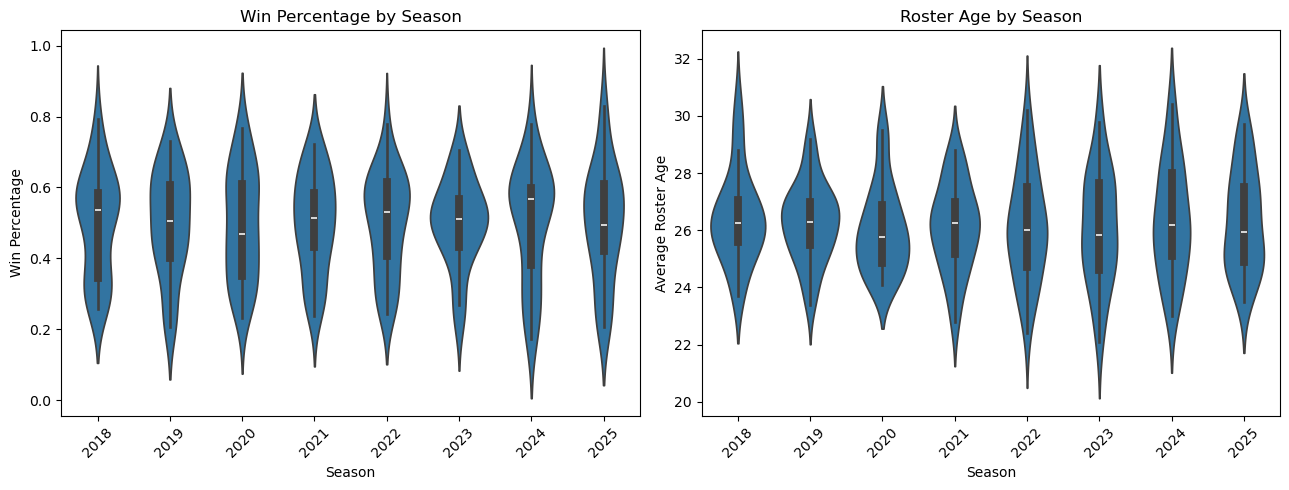

This plots shows the percentage changes more by team and season than roster age, while roster age stays fairly stable overall.


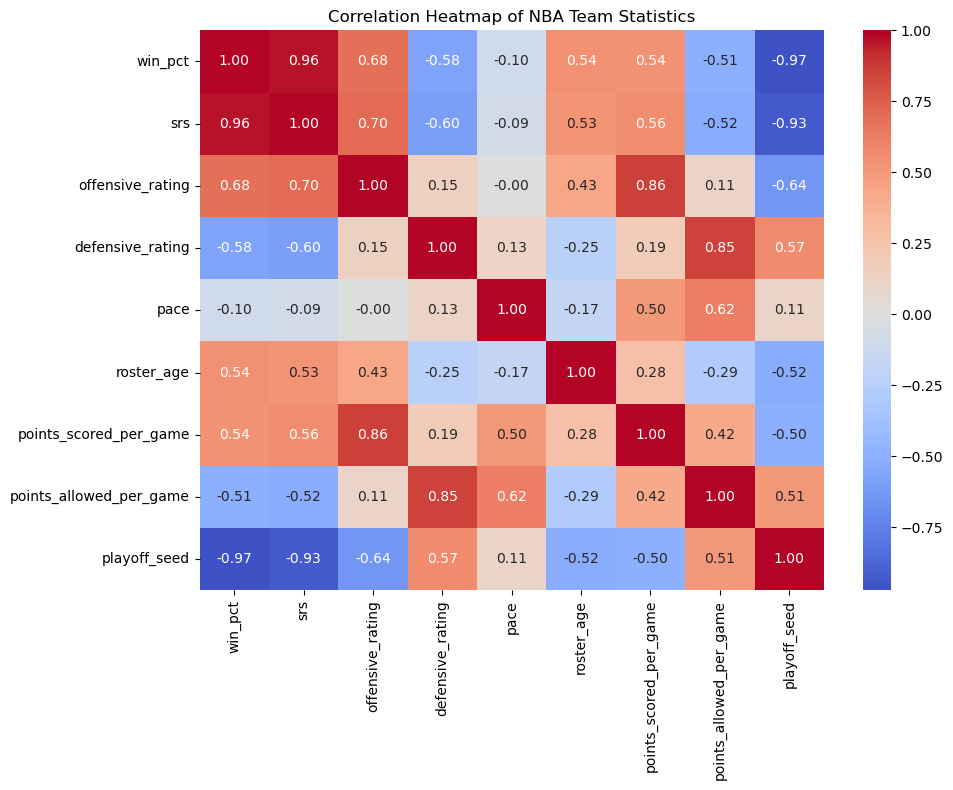

This is heatmap shows the correlation between each variable used in this dataset and helps us validate (correlation vs causation also as mentioned in class).
Analysis: SRS has a very strong relationship with win percentage (r = 0.96), while pace has a much weaker relationship (r = -0.10).


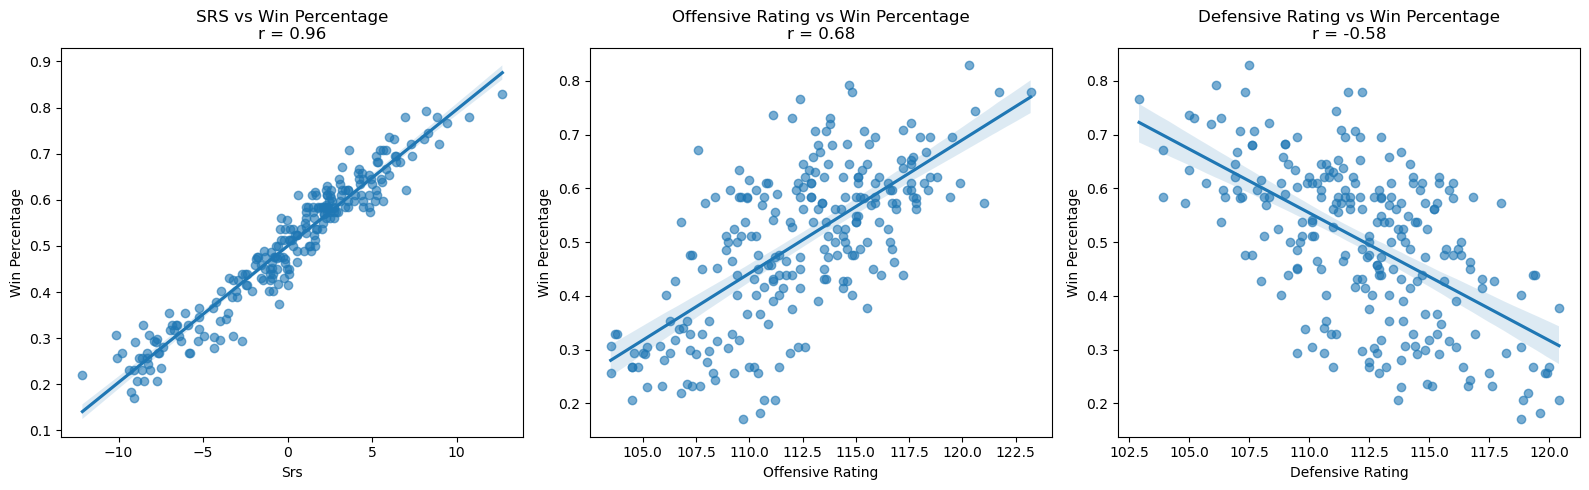

Analysis: SRS is the strongest predictor of winning here (r = 0.96); offense helps (r = 0.68), and better defense relates to more wins because defensive rating has a negative relationship (r = -0.58).


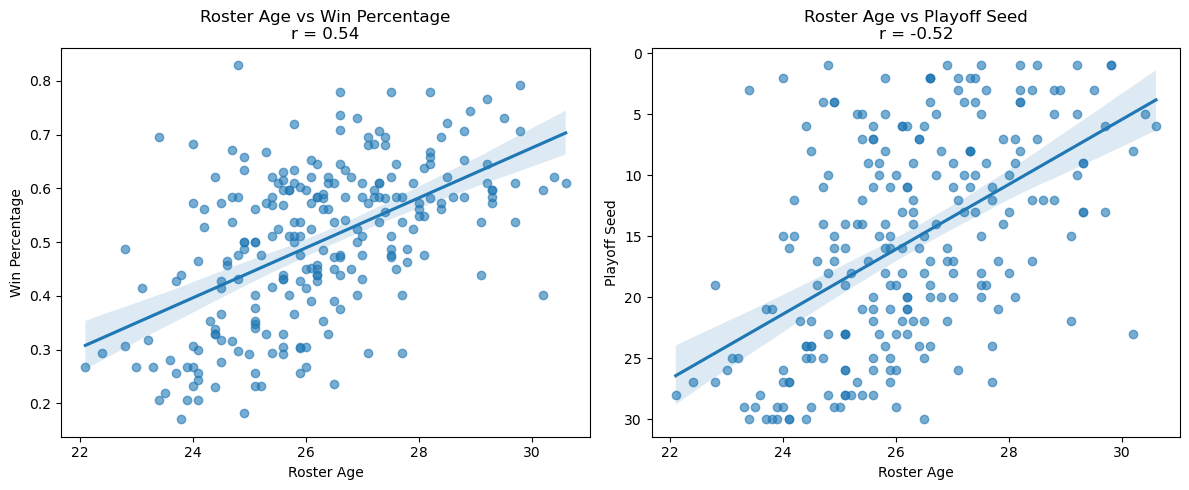

Analysis: Roster age is not strongly related to winning (r = 0.54) or playoff seed (r = -0.52), so age alone does not explain team success very well.


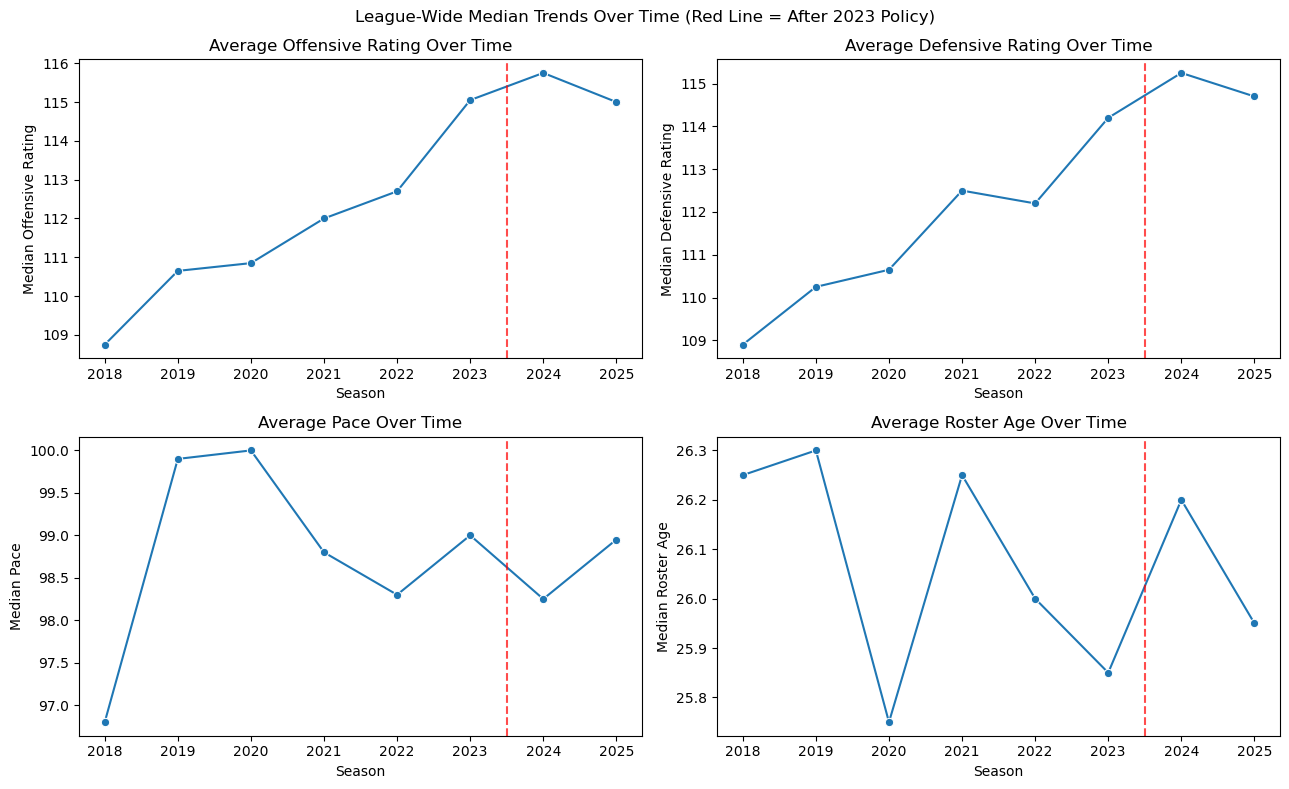

Analysis: Median offensive rating increased from 108.8 to 115.0, while median pace changed less from 96.8 to 98.9, showing scoring rose more than game speed.


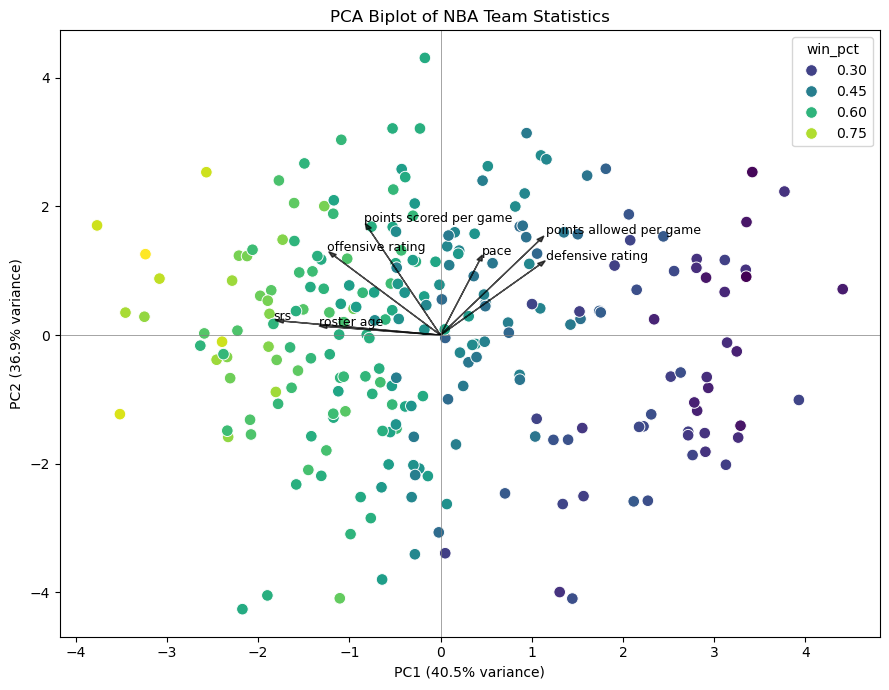

Analysis: PCA reduces the team stats into two main patterns, with PC1 explaining 40.5% of the variation and PC2 explaining 36.9%.


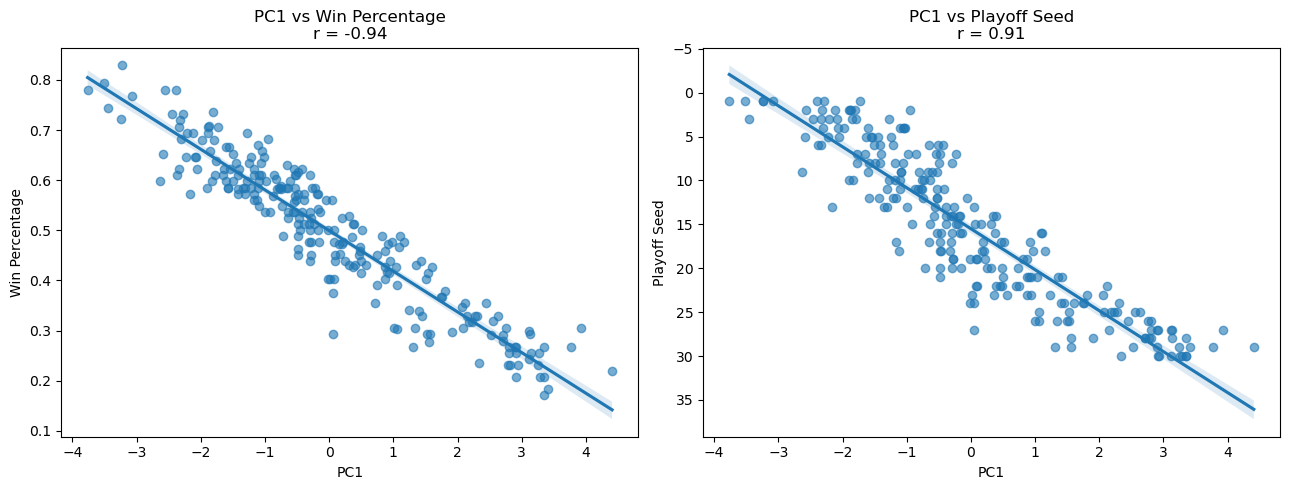

Analysis: PC1 strongly connects to team success because it relates strongly to win percentage (r = -0.94) and playoff seed (r = 0.91).


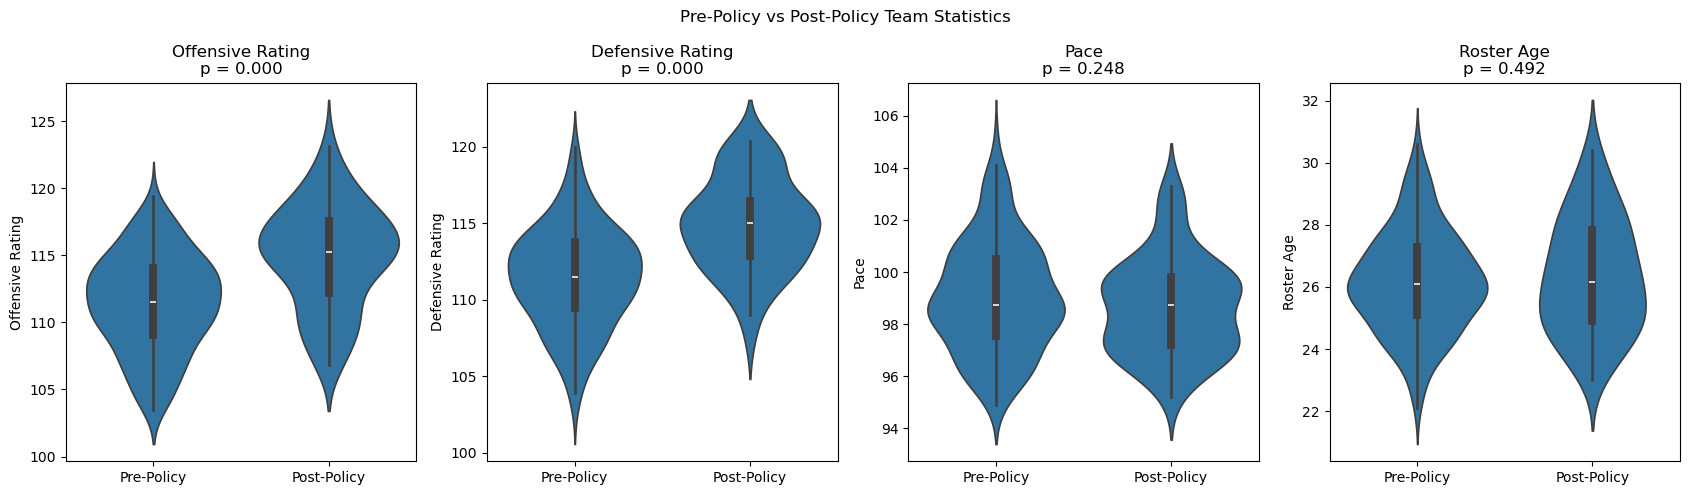

Analysis: The pre/post graphs mainly show whether team context changed after 2023; this is useful because major shifts could affect later analysis of the policy period.


In [18]:
# YOUR CODE HERE
#All the imported libraries and those either used in class or part of basic python libraries.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import glob

# The cleaned dataset can be found at data/02-processed
csvFiles = sorted(glob.glob("data/02-processed/nba_*final*.csv"))

allData = []

for fileName in csvFiles:
    yearData = pd.read_csv(fileName)
    allData.append(yearData)

df = pd.concat(allData, ignore_index=True)

#Tester to see if its working (Ignore)
print("Rows and columns:", df.shape)
print("Seasons:", sorted(df["season"].unique()))
print(df.head())


# Section 1: Analysis of the Basic Trends, Relationships, and Correlations

print("Plot 1: Win percentage and roster age distributions by season.")
fig,axes = plt.subplots(1, 2, figsize=(13, 5))

sns.violinplot(data=df, x="season", y="win_pct", ax=axes[0])
axes[0].set_title("Win Percentage by Season")
axes[0].set_xlabel("Season")
axes[0].set_ylabel("Win Percentage")
axes[0].tick_params(axis="x", rotation=45)

sns.violinplot(data=df, x="season", y="roster_age", ax=axes[1])
axes[1].set_title("Roster Age by Season")
axes[1].set_xlabel("Season")
axes[1].set_ylabel("Average Roster Age")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

##MANAN REMOVE WHEN YOU GET CLARITY
print("This plots shows the percentage changes more by team and season than roster age, while roster age stays fairly stable overall.")


# Plot 2: Correlation table for the main team statistics.
correlationColumns = [
    "win_pct", "srs", "offensive_rating", "defensive_rating",
    "pace", "roster_age", "points_scored_per_game",
    "points_allowed_per_game", "playoff_seed"
]

#Manan REMOVE WHEN U ADD TO ANALYSIS
#SRS is simple rating system mention in the analysis

#Red shows positive correlation here and blue is negative for the variables.
correlationTable = df[correlationColumns].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlationTable, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation Heatmap of NBA Team Statistics")

plt.tight_layout()
plt.show()

srsWinCorrelation = correlationTable.loc["srs", "win_pct" ]
paceWinCorrelation = correlationTable.loc["pace", "win_pct"]

print("This is heatmap shows the correlation between each variable used in this dataset and helps us validate (correlation vs causation also as mentioned in class).")
print(f"Analysis: SRS has a very strong relationship with win percentage (r = {srsWinCorrelation:.2f}), while pace has a much weaker relationship (r = {paceWinCorrelation:.2f}).")


# Plot 3: Shows the main performance stats compared to win percentage.
fig,axes = plt.subplots(1, 3, figsize=(16, 5))

scatterPlots = [
    ("srs", "SRS vs Win Percentage"),
    ("offensive_rating", "Offensive Rating vs Win Percentage"),("defensive_rating", "Defensive Rating vs Win Percentage")
]

for i, (xColumn, graphTitle) in enumerate(scatterPlots):
    sns.regplot(data=df, x=xColumn, y="win_pct", ax=axes[i], scatter_kws={"alpha": 0.6})
    rValue, pValue = stats.pearsonr(df[xColumn], df["win_pct"])
    
    axes[i].set_title(graphTitle + f"\nr = {rValue:.2f}")
    axes[i].set_xlabel(xColumn.replace("_", " ").title())
    axes[i].set_ylabel("Win Percentage")

plt.tight_layout()
plt.show()

srsR, srsP = stats.pearsonr(df["srs"], df["win_pct"])
offenseR, offenseP = stats.pearsonr(df["offensive_rating"], df["win_pct"])
defenseR, defenseP = stats.pearsonr(df["defensive_rating"], df["win_pct"])

print(f"Analysis: SRS is the strongest predictor of winning here (r = {srsR:.2f}); offense helps (r = {offenseR:.2f}), and better defense relates to more wins because defensive rating has a negative relationship (r = {defenseR:.2f}).")


# Plot 4: Here's the rosters age compared to win percentage and playoff seed.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.regplot(data=df, x="roster_age", y="win_pct", ax=axes[0], scatter_kws={"alpha": 0.6})
ageWinR, ageWinP = stats.pearsonr(df["roster_age"], df["win_pct"])
axes[0].set_title(f"Roster Age vs Win Percentage\nr = {ageWinR:.2f}")
axes[0].set_xlabel("Roster Age")
axes[0].set_ylabel("Win Percentage")

sns.regplot(data=df, x="roster_age", y="playoff_seed", ax=axes[1], scatter_kws={"alpha": 0.6})
ageSeedR, ageSeedP = stats.pearsonr(df["roster_age"], df["playoff_seed"])
axes[1].set_title(f"Roster Age vs Playoff Seed\nr = {ageSeedR:.2f}")
axes[1].set_xlabel("Roster Age")
axes[1].set_ylabel("Playoff Seed")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print(f"Analysis: Roster age is not strongly related to winning (r = {ageWinR:.2f}) or playoff seed (r = {ageSeedR:.2f}), so age alone does not explain team success very well.")


# Plot 5: League-wide median trends over time.
trendColumns = ["offensive_rating", "defensive_rating", "pace", "roster_age"]
seasonTrendTable = df.groupby("season")[trendColumns].median().reset_index()

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.flatten()

for i, columnName in enumerate(trendColumns):
    sns.lineplot(data=seasonTrendTable, x="season", y=columnName, marker="o", ax=axes[i])
    axes[i].axvline(2023.5, linestyle="--", color="red", alpha=0.7)
    axes[i].set_title("Average " + columnName.replace("_", " ").title() + " Over Time")
    axes[i].set_xlabel("Season")
    axes[i].set_ylabel("Median " + columnName.replace("_", " ").title())

plt.suptitle("League-Wide Median Trends Over Time (Red Line = After 2023 Policy)")
plt.tight_layout()
plt.show()

firstOffense = seasonTrendTable["offensive_rating"].iloc[0]
lastOffense = seasonTrendTable["offensive_rating"].iloc[-1]
firstPace = seasonTrendTable["pace"].iloc[0]
lastPace = seasonTrendTable["pace"].iloc[-1]

print(f"Analysis: Median offensive rating increased from {firstOffense:.1f} to {lastOffense:.1f}, while median pace changed less from {firstPace:.1f} to {lastPace:.1f}, showing scoring rose more than game speed.")

# Section 2: PCA and Pre/Post Policy Exploration
# Plot 6: PCA combines multiple stats into two main dimensions.
pcaColumns = [
    "srs", "offensive_rating", "defensive_rating",
    "pace", "roster_age", "points_scored_per_game",
    "points_allowed_per_game"
]

pcaData = df[pcaColumns].dropna()

scaler = StandardScaler()
scaledData = scaler.fit_transform(pcaData)

pcaModel = PCA(n_components=2)
pcaScores = pcaModel.fit_transform(scaledData)

pcaTable = df.loc[pcaData.index, ["team", "season", "win_pct", "playoff_seed"]].copy()
pcaTable["PC1"] = pcaScores[:, 0]
pcaTable["PC2"] = pcaScores[:, 1]

loadingTable = pd.DataFrame(
    pcaModel.components_.T,
    columns=["PC1", "PC2"],
    index=pcaColumns
)

plt.figure(figsize=(9, 7))
sns.scatterplot(data=pcaTable, x="PC1", y="PC2", hue="win_pct", palette="viridis", s=70)

for statName in loadingTable.index:
    plt.arrow(0, 0, loadingTable.loc[statName, "PC1"] * 3, loadingTable.loc[statName, "PC2"] * 3,
              color="black", alpha=0.7, head_width=0.06)
    plt.text(loadingTable.loc[statName, "PC1"] * 3.2, loadingTable.loc[statName, "PC2"] * 3.2,
             statName.replace("_", " "), fontsize=9)

plt.title("PCA Biplot of NBA Team Statistics")
plt.xlabel(f"PC1 ({pcaModel.explained_variance_ratio_[0] * 100:.1f}% variance)")
plt.ylabel(f"PC2 ({pcaModel.explained_variance_ratio_[1] * 100:.1f}% variance)")
plt.axhline(0, color="gray", linewidth=0.5)
plt.axvline(0, color="gray", linewidth=0.5)
plt.tight_layout()
plt.show()

pc1Variance = pcaModel.explained_variance_ratio_[0] * 100
pc2Variance = pcaModel.explained_variance_ratio_[1] * 100

print(f"Analysis: PCA reduces the team stats into two main patterns, with PC1 explaining {pc1Variance:.1f}% of the variation and PC2 explaining {pc2Variance:.1f}%.")


# Plot 7: PC1 compared to actual team outcomes.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.regplot(data=pcaTable, x="PC1", y="win_pct", ax=axes[0], scatter_kws={"alpha": 0.6})
pc1WinR, pc1WinP = stats.pearsonr(pcaTable["PC1"], pcaTable["win_pct"])
axes[0].set_title(f"PC1 vs Win Percentage\nr = {pc1WinR:.2f}")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("Win Percentage")

sns.regplot(data=pcaTable, x="PC1", y="playoff_seed", ax=axes[1], scatter_kws={"alpha": 0.6})
pc1SeedR, pc1SeedP = stats.pearsonr(pcaTable["PC1"], pcaTable["playoff_seed"])
axes[1].set_title(f"PC1 vs Playoff Seed\nr = {pc1SeedR:.2f}")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("Playoff Seed")

axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print(f"Analysis: PC1 strongly connects to team success because it relates strongly to win percentage (r = {pc1WinR:.2f}) and playoff seed (r = {pc1SeedR:.2f}).")


# Plot 8: Key stats before and after the 2023 policy period.
df["policyPeriod"] = np.where(df["season"] <= 2023, "Pre-Policy", "Post-Policy")

policyColumns = ["offensive_rating", "defensive_rating", "pace", "roster_age"]

fig, axes = plt.subplots(1, 4, figsize=(17, 5))

for i, columnName in enumerate(policyColumns):
    sns.violinplot(data=df, x="policyPeriod", y=columnName, ax=axes[i])

    preValues = df[df["policyPeriod"] == "Pre-Policy"][columnName]
    postValues = df[df["policyPeriod"] == "Post-Policy"][columnName]
    tValue, pValue = stats.ttest_ind(preValues, postValues)

    axes[i].set_title(columnName.replace("_", " ").title() + f"\np = {pValue:.3f}")
    axes[i].set_xlabel("")
    axes[i].set_ylabel(columnName.replace("_", " ").title())

plt.suptitle("Pre-Policy vs Post-Policy Team Statistics")
plt.tight_layout()
plt.show()

print("Analysis: The pre/post graphs mainly show whether team context changed after 2023; this is useful because major shifts could affect later analysis of the policy period.")

#### Section 2 of EDA if you need it  - please give it a better title than this

Some more words and stuff.  Remember notebooks work best if you interleave the code that generates a result with properly annotate figures and text that puts these results into context.

In [ ]:
## YOUR CODE HERE
## FEEL FREE TO ADD MULTIPLE CELLS PER SECTION

## Ethics


### A. Data Collection
 - [X] **A.1 Informed consent**: If there are human subjects, have they given informed consent, where subjects affirmatively opt-in and have a clear understanding of the data uses to which they consent?
> Not applicable. All data comes from publicly available sources (Basketball Reference, NBA injury reports, ProSportsTransactions). There are no human subjects being surveyed or recruited, we are analyzing records that are already public.

 - [X] **A.2 Collection bias**: Have we considered sources of bias that could be introduced during data collection and survey design and taken steps to mitigate those?

 > Teams have a financial incentive to mislabel strategic rest as injury post-2023 to avoid fines, meaning our "strategic rest" label may be undercounted in later seasons. We could address this by flagging single-game absences labeled as minor injuries as likely strategic rest, since real injuries typically cause players to miss multiple games. Additionally, players being heavily rested may accumulate fewer minutes and fall out of our top-3 threshold entirely, further undercounting rest for the most load-managed players.

 - [X] **A.3 Limit PII exposure**: Have we considered ways to minimize exposure of personally identifiable information (PII) for example through anonymization or not collecting information that isn't relevant for analysis?

>Not applicable. We are only working with publicly reported player performance and availability data. No private or personally identifiable information is collected or stored beyond what is already publicly published by the NBA and its official partners.

 - [X] **A.4 Downstream bias mitigation**: Have we considered ways to enable testing downstream results for biased outcomes (e.g., collecting data on protected group status like race or gender)?

 >  Relevant. Our analysis focuses on top-3 minutes leaders, who are disproportionately high-profile players with access to load management that role players rarely receive despite similar fatigue. Conclusions about rest and winning apply specifically to high-usage players and should not be generalized to the broader roster. For the secondary analysis, findings about policy effects are further limited to players with prior All-Star or All-NBA recognition and should not be extended beyond that group.


### B. Data Storage
 - [X] **B.1 Data security**: Do we have a plan to protect and secure data (e.g., encryption at rest and in transit, access controls on internal users and third parties, access logs, and up-to-date software)?

 > Low risk. All data used is publicly available and contains no sensitive personal information. We do not store any private data, so standard security concerns around encryption and access controls are minimal for this project.

 - [X] **B.2 Right to be forgotten**: Do we have a mechanism through which an individual can request their personal information be removed?

> Not applicable. We do not collect any personal data that individuals would have a right to request removed. All player records used are part of the official public NBA historical record.

 - [X] **B.3 Data retention plan**: Is there a schedule or plan to delete the data after it is no longer needed?
> Not applicable. Since all our data comes from public sources that are independently maintained, there is no unique dataset we are generating that would require a formal retention or deletion plan.


### C. Analysis
 - [X] **C.1 Missing perspectives**: Have we sought to address blindspots in the analysis through engagement with relevant stakeholders (e.g., checking assumptions and discussing implications with affected communities and subject matter experts)?

 > This is relevant. Our analysis relies entirely on publicly observable data and does not incorporate the perspectives of players, team medical staff, or player unions, all of whom have direct knowledge of how rest decisions are actually made. To partially address this limitation, we will cross-check our rest classifications with publicly available player or coach statements when possible, while remaining transparent about the fact that our data cannot fully capture the true motivations behind player absences.

 - [X] **C.2 Dataset bias**: Have we examined the data for possible sources of bias and taken steps to mitigate or address these biases (e.g., stereotype perpetuation, confirmation bias, imbalanced classes, or omitted confounding variables)?

 > This is relevant. Since our dataset relies on team-reported injury labels, instances where teams may classify strategic rest as minor injury to avoid fines are likely embedded in the data itself. We will therefore flag unusual outliers and note cases where team-level patterns appear inconsistent.

 - [X] **C.3 Honest representation**: Are our visualizations, summary statistics, and reports designed to honestly represent the underlying data?

 > This is relevant. Our rest variable is an approximation, not a directly observed fact. All visualizations will clearly state it is a constructed proxy.

 - [X] **C.4 Privacy in analysis**: Have we ensured that data with PII are not used or displayed unless necessary for the analysis?
 - [X] **C.5 Auditability**: Is the process of generating the analysis well documented and reproducible if we discover issues in the future?

 > Our data sources, classification rules, and analysis steps will be fully documented in our repository so methods can be reviewed and reproduced.

### D. Modeling
 - [X] **D.1 Proxy discrimination**: Have we ensured that the model does not rely on variables or proxies for variables that are unfairly discriminatory?

 > This is relevant. We use player absence patterns as a proxy for health-related rest decisions, but this measure may vary across teams because of differences in reporting culture or organizational incentives rather than true differences in rest behavior. 

 - [X] **D.2 Fairness across groups**: Have we tested model results for fairness with respect to different affected groups (e.g., tested for disparate error rates)?
 - [X] **D.3 Metric selection**: Have we considered the effects of optimizing for our defined metrics and considered additional metrics?
 - [X] **D.4 Explainability**: Can we explain in understandable terms a decision the model made in cases where a justification is needed?
 - [X] **D.5 Communicate limitations**: Have we communicated the shortcomings, limitations, and biases of the model to relevant stakeholders in ways that can be generally understood?

 > We will clearly state that our findings show association not causation, and that our rest variable is subject to reporting bias.

### E. Deployment
 - [X] **E.1 Monitoring and evaluation**: Do we have a clear plan to monitor the model and its impacts after it is deployed (e.g., performance monitoring, regular audit of sample predictions, human review of high-stakes decisions, reviewing downstream impacts of errors or low-confidence decisions, testing for concept drift)?
 - [X] **E.2 Redress**: Have we discussed with our organization a plan for response if users are harmed by the results (e.g., how does the data science team evaluate these cases and update analysis and models to prevent future harm)?
 - [X] **E.3 Roll back**: Is there a way to turn off or roll back the model in production if necessary?
 - [X] **E.4 Unintended use**: Have we taken steps to identify and prevent unintended uses and abuse of the model and do we have a plan to monitor these once the model is deployed?

 > This is also relevant. If our findings suggest that rest has little measurable effect on performance, they could be misinterpreted as an argument against load management despite its importance for player health. We will therefore make clear that our analysis is descriptive in nature and should not be treated as a direct policy recommendation.


## Team Expectations 

Instructions: REPLACE the contents of this cell with your work, including any updates to recover points lost in your proposal feedback

## Project Timeline Proposal

Instructions: Replace this with your timeline.  **PLEASE UPDATE your Timeline!** No battle plan survives contact with the enemy, so make sure we understand how your plans have changed.  Also if you have lost points on the previous checkpoint fix them